# About the Dataset

The Google Play Store User Reviews dataset contains reviews written by users for different Android applications.

Each row represents one user review.

The dataset helps us understand user opinions about different apps.

It contains information such as:

- App Name
- User Review
- Sentiment (Positive, Negative, Neutral)
- Sentiment Polarity
- Sentiment Subjectivity

This dataset is mainly used for sentiment analysis and understanding customer feedback.

# Objective

The main objective of this project is to analyze user reviews and classify them into Positive, Negative, and Neutral sentiments.

This helps us understand how users feel about different applications and identify which app categories receive better user feedback.

In [3]:
#1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
# load dataset
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [7]:
# view dataset 
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [9]:
reviews.head(15)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000
5,10 Best Foods for You,Best way,Positive,1.000000,0.300000
6,10 Best Foods for You,Amazing,Positive,0.600000,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.000000,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.000000,0.000000


In [11]:
reviews.shape

(64295, 5)

### Observation

The shape() function shows the total number of rows and columns in the dataset.

- 5 columns and 64295 row

In [17]:
# Dataset Information
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


### Observation

The dataset contains both text and numerical columns.

Some columns contain missing values which need to be handled before analysis.

In [23]:
#Describe
reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


### Missing Values

In [26]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

### Observation

The dataset contains a large number of missing values.

- App → 0 missing values
- Translated_Review → 26868 missing values
- Sentiment → 26863 missing values
- Sentiment_Polarity → 26863 missing values
- Sentiment_Subjectivity → 26863 missing values

The **App** column is complete, but the review and sentiment columns contain many missing values.


### Duplicate Values

In [30]:
reviews.duplicated().sum()

33616

- I have 33616 duplicate values found in this data set
-  after that i fill the duplicate values
-  after that i have no dupilcate values

#### Remove Duplicate Values

In [35]:
reviews.drop_duplicates(inplace=True)

In [37]:
reviews.duplicated().sum()

0

#### Handle Missing Values

In [43]:
reviews.dropna(inplace=True)

In [45]:
reviews.isnull().sum()

App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

### Sentiment Distribution

In [48]:
reviews["Sentiment"].value_counts()

Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64

### Bar graph

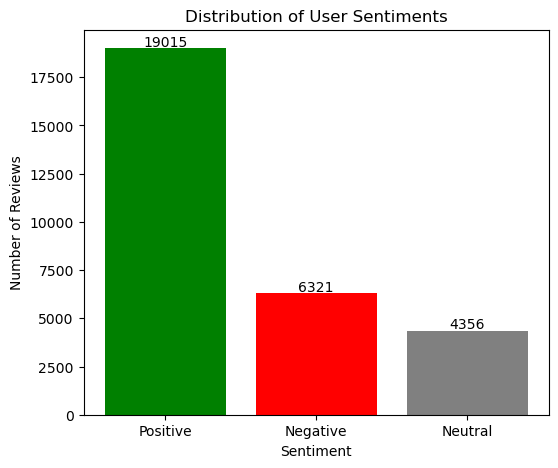

In [51]:
import matplotlib.pyplot as plt

sentiment_count = reviews["Sentiment"].value_counts()

colors = ["green", "red", "gray"]

plt.figure(figsize=(6,5))
plt.bar(sentiment_count.index,
        sentiment_count.values,
        color=colors)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Distribution of User Sentiments")

for i,v in enumerate(sentiment_count.values):
    plt.text(i,v+100,str(v),ha="center")

plt.show()

### Observation

- The graph shows the distribution of Positive, Negative, and Neutral reviews.
- In this grpah show the positive values , like green high review 

- Positive reviews are the highest, which means most users are satisfied with the apps.

- Negative reviews are fewer, while Neutral reviews are in between.

- Overall, users have a positive opinion about most applications.

#### Sentiment by Category

In [58]:
playstore = pd.read_csv("googleplaystore.csv")

In [60]:
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [62]:
merged_data = pd.merge(
    playstore,
    reviews,
    on="App",
    how="inner"
)

In [64]:
merged_data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


In [66]:
positive = merged_data[merged_data["Sentiment"]=="Positive"]["Category"].value_counts()

positive

Category
GAME                   5839
FAMILY                 2409
HEALTH_AND_FITNESS     2155
PRODUCTIVITY           1398
SPORTS                 1326
TRAVEL_AND_LOCAL       1286
MEDICAL                1180
DATING                 1102
PHOTOGRAPHY            1083
FINANCE                1065
TOOLS                  1013
COMMUNICATION           886
PERSONALIZATION         837
SHOPPING                822
ENTERTAINMENT           813
BUSINESS                777
NEWS_AND_MAGAZINES      773
EDUCATION               693
LIFESTYLE               647
SOCIAL                  582
FOOD_AND_DRINK          551
BOOKS_AND_REFERENCE     512
HOUSE_AND_HOME          354
ART_AND_DESIGN          240
LIBRARIES_AND_DEMO      237
AUTO_AND_VEHICLES       230
VIDEO_PLAYERS           185
PARENTING               181
BEAUTY                  176
WEATHER                 158
MAPS_AND_NAVIGATION     126
EVENTS                  123
COMICS                   72
Name: count, dtype: int64

In [68]:
negative = merged_data[merged_data["Sentiment"]=="Negative"]["Category"].value_counts()

negative

Category
GAME                   3746
FAMILY                 1041
SPORTS                  493
TRAVEL_AND_LOCAL        453
DATING                  395
PRODUCTIVITY            382
FINANCE                 362
ENTERTAINMENT           327
SOCIAL                  326
NEWS_AND_MAGAZINES      323
PHOTOGRAPHY             318
HEALTH_AND_FITNESS      311
TOOLS                   296
COMMUNICATION           280
MEDICAL                 274
SHOPPING                267
BUSINESS                212
PERSONALIZATION         201
LIFESTYLE               189
BOOKS_AND_REFERENCE     112
EDUCATION               111
FOOD_AND_DRINK          100
HOUSE_AND_HOME           98
VIDEO_PLAYERS            83
BEAUTY                   60
ART_AND_DESIGN           54
LIBRARIES_AND_DEMO       51
WEATHER                  33
MAPS_AND_NAVIGATION      27
PARENTING                23
AUTO_AND_VEHICLES        17
EVENTS                   16
COMICS                    2
Name: count, dtype: int64

#### Positive Reviews by Category"

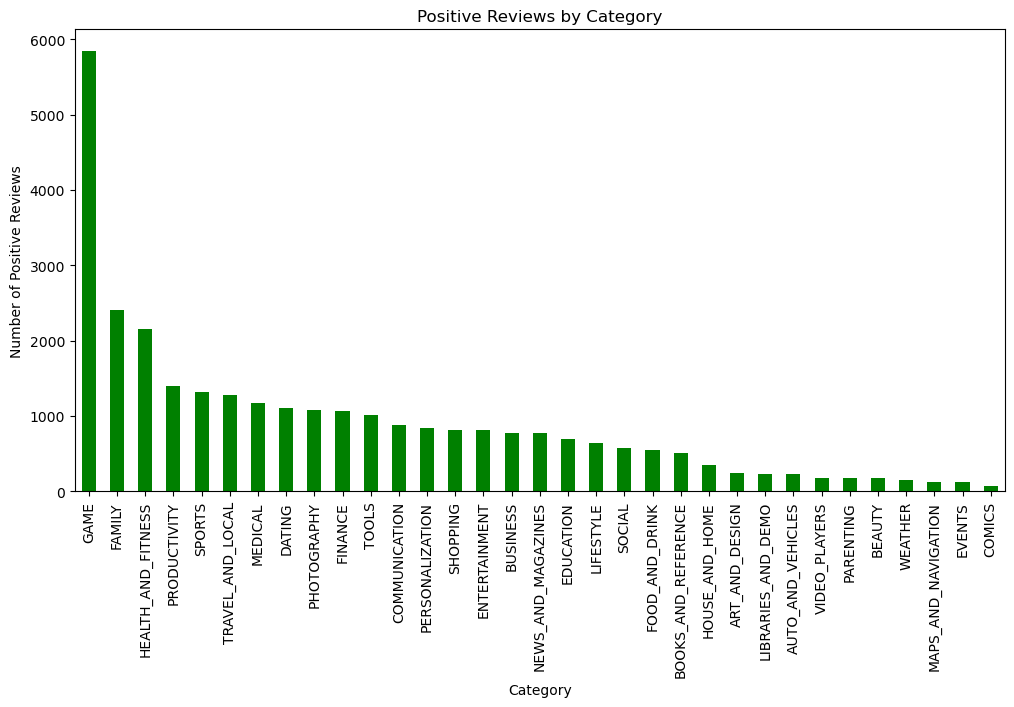

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

positive.plot(
    kind="bar",
    color="green"
)

plt.title("Positive Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Number of Positive Reviews")

plt.xticks(rotation=90)

plt.show()

### Positive Reviews by Category Analysis

This graph shows the number of positive reviews received by each app category.

The GAME category has the highest number of positive reviews (around 5800). This means users are highly satisfied with gaming apps.

The FAMILY category has the second highest number of positive reviews, followed by HEALTH_AND_FITNESS and PRODUCTIVITY.

Categories like EVENTS, MAPS_AND_NAVIGATION, BEAUTY, and COMICS have very few positive reviews. This may be because these categories have fewer apps or fewer users.

Overall, the graph shows that GAME and FAMILY apps receive the highest positive user feedback. Developers can learn from these successful categories and focus on creating high-quality, user-friendly applications.

#### Negative Reviews Graph

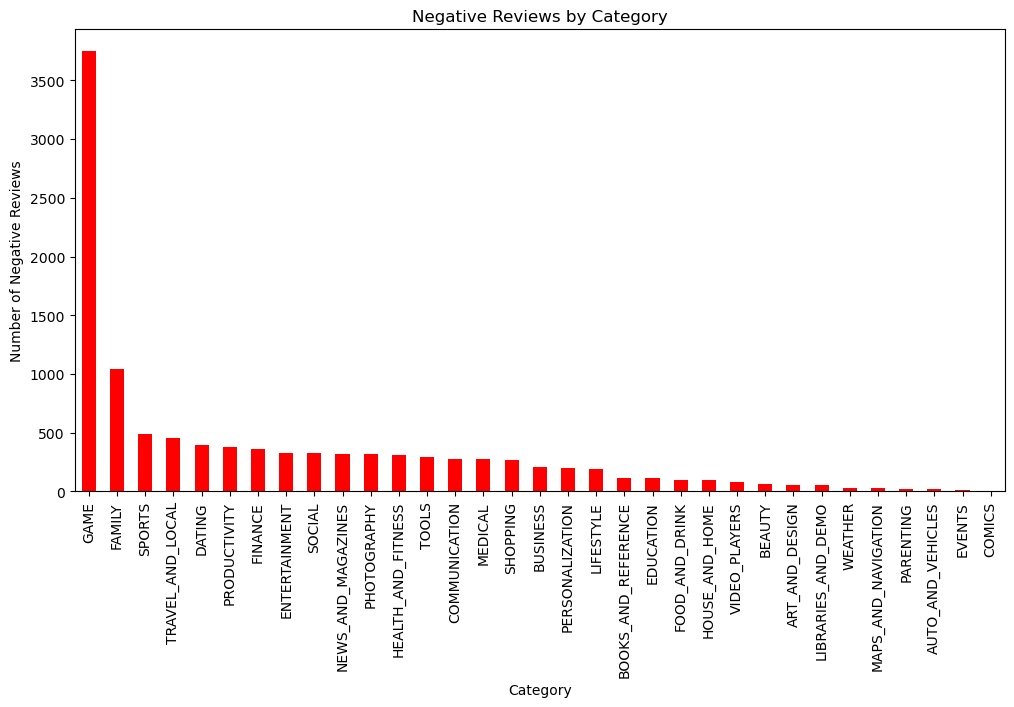

In [74]:
plt.figure(figsize=(12,6))

negative.plot(
    kind="bar",
    color="red"
)

plt.title("Negative Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Number of Negative Reviews")

plt.xticks(rotation=90)

plt.show()

### Negative Reviews by Category Analysis

This graph shows the number of negative reviews received by each app category.

The GAME category has the highest number of negative reviews (around 3700). This means gaming apps receive many complaints from users, possibly because of bugs, ads, or performance issues.

The FAMILY category has the second highest number of negative reviews.

Categories such as SPORTS, TRAVEL_AND_LOCAL, DATING, PRODUCTIVITY, and FINANCE also have a moderate number of negative reviews.

Categories like COMICS, EVENTS, AUTO_AND_VEHICLES, PARENTING, and MAPS_AND_NAVIGATION have very few negative reviews.

Overall, the graph shows that GAME and FAMILY categories have the highest number of negative reviews. Developers should improve app performance, fix bugs, reduce crashes, and regularly update their apps to improve user satisfaction.

In [ ]:
#Find Top 5 Positive Categories

In [80]:
positive.head(5)

Category
GAME                  5839
FAMILY                2409
HEALTH_AND_FITNESS    2155
PRODUCTIVITY          1398
SPORTS                1326
Name: count, dtype: int64

In [ ]:
#Find Top 5 Negative Categories


In [78]:
negative.head()

Category
GAME                3746
FAMILY              1041
SPORTS               493
TRAVEL_AND_LOCAL     453
DATING               395
Name: count, dtype: int64

In [ ]:
#At least one interactive visualization using Plotly

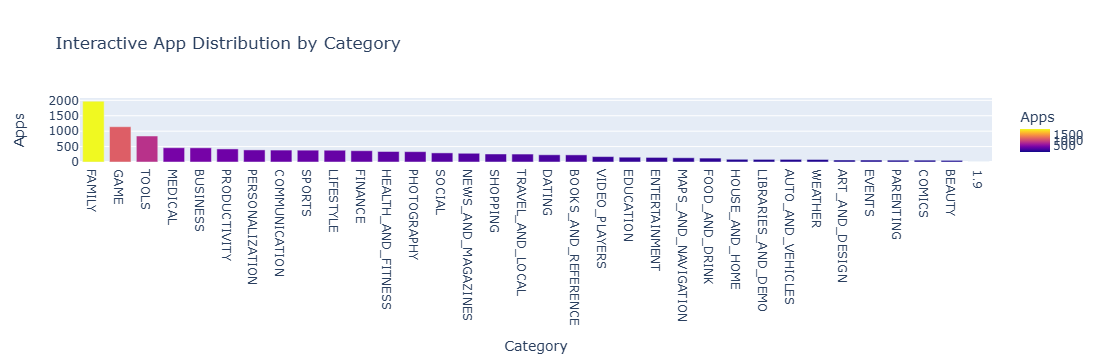

In [90]:
import plotly.express as px

category_count = playstore["Category"].value_counts().reset_index()

category_count.columns = ["Category", "Apps"]

fig = px.bar(
    category_count,
    x="Category",
    y="Apps",
    color="Apps",
    title="Interactive App Distribution by Category"
)

fig.show()

### Interactive Visualization Analysis

This interactive bar chart shows the number of apps available in each category on the Google Play Store.

The FAMILY category has the highest number of apps (around 1943), which shows that it is the most popular and competitive category.

The GAME category has the second highest number of apps, followed by TOOLS and BUSINESS.

Categories such as BEAUTY, COMICS, PARENTING, and EVENTS have the lowest number of apps.

The graph is interactive, so users can zoom in, zoom out, and move the cursor over the bars to see the exact number of apps in each category.

Overall, the chart helps us understand which categories are highly competitive and which have fewer apps.

In [ ]:
#Data-Driven Insights for a Developer Planning to Launch a New App

# Conclusion

### Insight 1
The FAMILY category has the highest number of apps. This means the competition is very high in this category. A new developer should create unique features to stand out.

### Insight 2
Most apps on the Google Play Store are free. Free apps with good ratings and useful features have a better chance of getting more downloads.

### Insight 3
Positive user reviews are more common than negative reviews. Developers should focus on app quality, regular updates, and bug fixes to keep users satisfied and improve ratings.